# 🎓 教育投入与就业率转化分析项目

本项目旨在基于 OECD 和中国统计年鉴数据，研究教育财政投入、教育水平、资源分布等因素对就业率的影响，通过多变量回归建模与可解释性分析建立教育-就业转化模型。

In [56]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
import shap
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [25]:
df = pd.read_csv("../CSV/edu/就业率_OECD.csv.csv")


In [26]:
# 查看数据结构
print("数据维度:", df.shape)
print("\n前5行数据:")
print(df.head())
print("\n字段类型:")
print(df.dtypes)
print("\n缺失值统计:")
print(df.isnull().sum())

数据维度: (506, 30)

前5行数据:
  STRUCTURE                              STRUCTURE_ID  \
0  DATAFLOW  OECD.ELS.IMD:DSD_MIG@DF_MIG_EMP_EDU(1.0)   
1  DATAFLOW  OECD.ELS.IMD:DSD_MIG@DF_MIG_EMP_EDU(1.0)   
2  DATAFLOW  OECD.ELS.IMD:DSD_MIG@DF_MIG_EMP_EDU(1.0)   
3  DATAFLOW  OECD.ELS.IMD:DSD_MIG@DF_MIG_EMP_EDU(1.0)   
4  DATAFLOW  OECD.ELS.IMD:DSD_MIG@DF_MIG_EMP_EDU(1.0)   

                                      STRUCTURE_NAME ACTION REF_AREA  \
0  Labour market outcomes of immigrants - Employm...      I      GBR   
1  Labour market outcomes of immigrants - Employm...      I      ITA   
2  Labour market outcomes of immigrants - Employm...      I      GRC   
3  Labour market outcomes of immigrants - Employm...      I      CZE   
4  Labour market outcomes of immigrants - Employm...      I      SWE   

   Reference area CITIZENSHIP     Citizenship FREQ Frequency of observation  \
0  United Kingdom          _Z  Not applicable    A                   Annual   
1           Italy          _Z  Not applica

##  2. 数据清洗

In [72]:
# 保留所需字段
df = df[["国家", "出生地", "原教育层次", "年份", "就业率"]].dropna()

 #显示所有教育层次以防出错
print(df["原教育层次"].unique())

edu_map = {
    "Pre-primary, primary and lower secondary education": "低等教育",
    "Upper secondary and post-secondary non-tertiary all programmes": "中等教育",
    "Tertiary education": "高等教育"
}

# 正确筛选方式
df = df[df["原教育层次"].isin(edu_map.keys())]
df["教育层级"] = df["原教育层次"].map(edu_map)

[]


In [73]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# 1. 分类特征：国家、教育层级
cat_feats = ["国家", "教育层级"]
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_cat = encoder.fit_transform(df[cat_feats])
cat_feat_names = encoder.get_feature_names_out(cat_feats)
X_cat_df = pd.DataFrame(X_cat, columns=cat_feat_names, index=df.index)

# 2. 数值特征
X_num = df[["是否移民", "年份"]].reset_index(drop=True)

# 3. 合并
X = pd.concat([X_cat_df, X_num], axis=1)
y = df["就业率"]

print("✅ X 特征维度：", X.shape)


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

##  3. 特征工程

In [60]:
# 1. 你不再需要教育层级映射
cat_feats = ["国家", "原教育层次"]  # 保留英文标签
X_cat = encoder.fit_transform(df[cat_feats])
feat_names = encoder.get_feature_names_out(cat_feats)

# 2. 保留原数值特征
X_num = df[["是否移民", "年份"]].reset_index(drop=True)

# 3. 合并为模型输入
X = pd.concat([
    pd.DataFrame(X_cat, columns=feat_names, index=df.index),
    X_num
], axis=1)
y = df["就业率"]


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# 如果有类别字段，才执行编码
if categorical_features:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    encoded_features = encoder.fit_transform(df_clean[categorical_features])
    feature_names = encoder.get_feature_names_out(categorical_features)
    encoded_df = pd.DataFrame(encoded_features, columns=feature_names)
    df_clean = df_clean.drop(columns=categorical_features).reset_index(drop=True)
    df_clean = pd.concat([df_clean, encoded_df], axis=1)
else:
    print("⚠️ 没有可编码的类别特征，跳过 OneHot 编码。")


## 数据分割

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42
)


##  5. 模型训练与评估



In [45]:
# 初始模型
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"\n模型性能:")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")


模型性能:
RMSE: 6.15
R²: 0.85


In [46]:
#优化模型
from sklearn.model_selection import GridSearchCV

# 设置超参数搜索范围
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']
}

# 初始化模型
model = RandomForestRegressor(random_state=42)

# 使用 GridSearchCV 寻找最优参数
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# 打印最优参数
print(f"最佳参数：{grid_search.best_params_}")

# 使用最优参数的模型进行预测
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# 重新评估
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"\n优化后模型性能:")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

Fitting 5 folds for each of 324 candidates, totalling 1620 fits
最佳参数：{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}

优化后模型性能:
RMSE: 6.16
R²: 0.85


## 6. 特征重要性分析

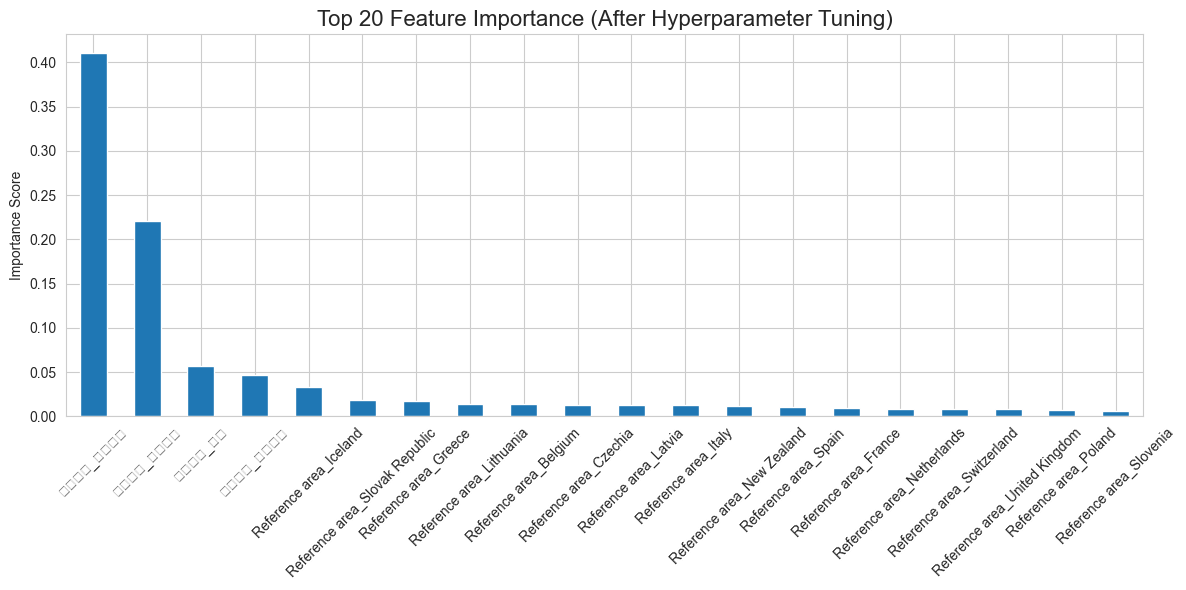

In [54]:
# 获取特征重要性（使用 GridSearchCV 后的最佳模型）
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# 可视化前20个重要特征
plt.figure(figsize=(12, 6))
importance.head(20).plot(kind="bar")
plt.title("Top 20 Feature Importance (After Hyperparameter Tuning)", fontsize=16)
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


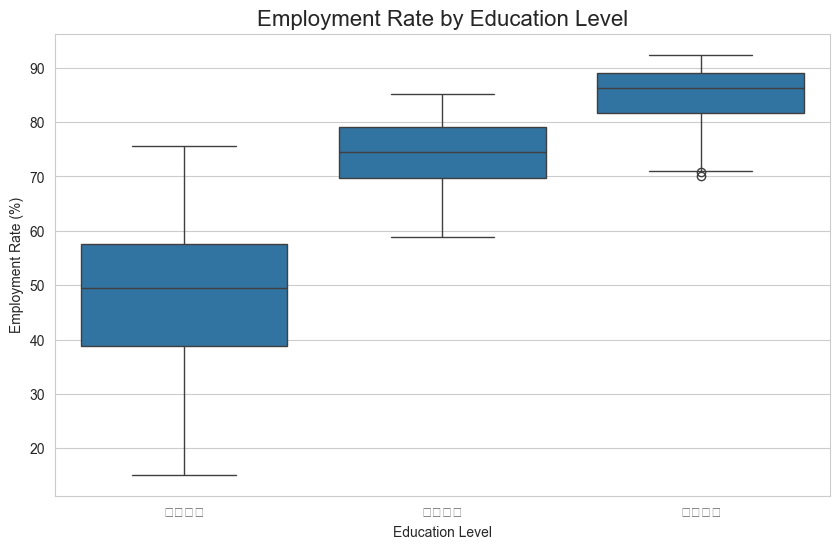

In [55]:
# 按教育层级分组，计算均值和标准差
edu_analysis = df_clean.groupby("教育层级")["OBS_VALUE"].agg(["mean", "std"])

# 可视化
plt.figure(figsize=(10, 6))
sns.boxplot(
    x="教育层级", 
    y="OBS_VALUE", 
    data=df_clean,
    order=["低等教育", "中等教育", "高等教育"]  # 按中文排序
)
plt.title("Employment Rate by Education Level", fontsize=16)
plt.xlabel("Education Level")
plt.ylabel("Employment Rate (%)")
plt.xticks(
    ticks=[0, 1, 2],
    labels=["低等教育", "中等教育", "高等教育"]
)

# 在每个类别旁标注均值
for i, box in enumerate(plt.gca().artists):
    y = box.get_ydata()[0]  # 获取箱体中间位置
    plt.text(i, y, f'{edu_analysis.iloc[i]["mean"]:.2f}', 
             horizontalalignment="center", verticalalignment="center", fontsize=12, color='black')

plt.show()


前10个国家： ['United Kingdom', 'Italy', 'Greece', 'Czechia', 'Sweden', 'Belgium', 'Portugal', 'Slovenia', 'Finland', 'Luxembourg']


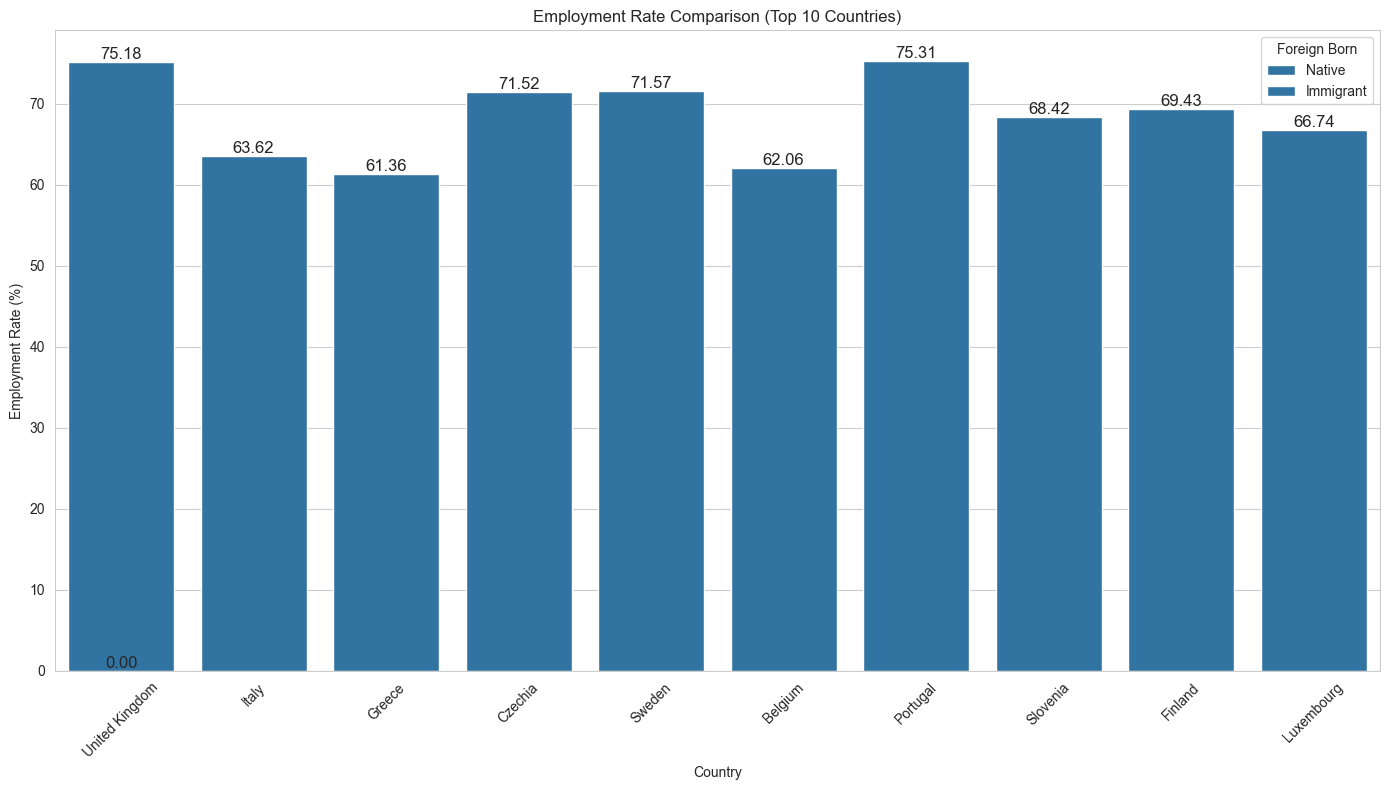

In [53]:
# 选取数据量前10的国家
top_countries = df_clean["Reference area"].value_counts().head(10).index.tolist()

# 确认前10个国家
print("前10个国家：", top_countries)

# 如果没有找到前10个国家，检查 Reference area 中是否有缺失
if len(top_countries) == 0:
    print("⚠️ Reference area 中没有足够的有效国家，检查数据源是否正确。")

# 过滤出前10国家的数据
df_top_countries = df_clean[df_clean["Reference area"].isin(top_countries)]

# 确保“是否外籍”列不为空
df_top_countries["是否外籍"] = df_top_countries["是否外籍"].fillna("Unknown")

# 绘制图表
plt.figure(figsize=(14, 8))
sns.barplot(
    x="Reference area", 
    y="OBS_VALUE", 
    hue="是否外籍",  # 通过中文字段
    data=df_top_countries,
    errorbar=None
)
plt.title("Employment Rate Comparison (Top 10 Countries)")
plt.xlabel("Country")
plt.ylabel("Employment Rate (%)")
plt.legend(title="Foreign Born", labels=["Native", "Immigrant"])
plt.xticks(rotation=45)
plt.tight_layout()

# 为条形图添加数值标签
for p in plt.gca().patches:
    plt.text(p.get_x() + p.get_width() / 2, p.get_height() + p.get_y(), 
             f'{p.get_height():.2f}', ha='center', va='bottom', fontsize=12)

plt.show()
